TF version: 2.19.0
Found 3788 images belonging to 2 classes.
Found 945 images belonging to 2 classes.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 45s 308ms/step - accuracy: 0.9047 - loss: 0.2087 - val_accuracy: 0.9937 - val_loss: 0.0285
Epoch 2/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 25s 211ms/step - accuracy: 0.9907 - loss: 0.0246 - val_accuracy: 0.9915 - val_loss: 0.0278
Epoch 3/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 25s 214ms/step - accuracy: 0.9962 - loss: 0.0151 - val_accuracy: 0.9905 - val_loss: 0.0309
Epoch 4/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 31s 262ms/step - accuracy: 0.9977 - loss: 0.0079 - val_accuracy: 0.9905 - val_loss: 0.0323
Epoch 5/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 27s 223ms/step - accuracy: 0.9981 - loss: 0.0064 - val_accuracy: 0.9915 - val_loss: 0.0316


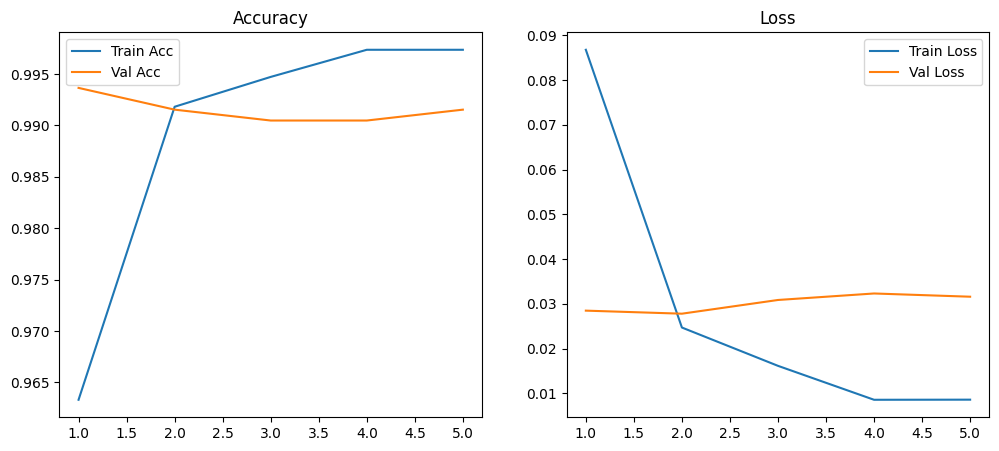

submission.csv created ✅
Upload dialog skipped (not supported in this environment).


In [3]:
# =========================
# 1. Imports
# =========================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

print("TF version:", tf.__version__)

# =========================
# 2. Paths (EDIT THESE)
# =========================
TRAIN_DIR = "/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/train"   # has subfolders per class
TEST_DIR  = "/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/kaggle_test_final"    # flat folder with test images

# =========================
# 3. Data Generators
# =========================
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

# =========================
# 4. Model (Transfer Learning)
# =========================
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =========================
# 5. Train
# =========================
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5
)

# =========================
# 6. Visualization
# =========================
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc)+1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, acc, label='Train Acc')
plt.plot(epochs, val_acc, label='Val Acc')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(epochs, loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()

# =========================
# 7. Predict on TEST set
# =========================
test_images = sorted(os.listdir(TEST_DIR))

predictions = []

for img_name in test_images:
    img_path = os.path.join(TEST_DIR, img_name)

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)[0][0]
    label = 1 if pred > 0.5 else 0
    predictions.append(label)

# =========================
# 8. Create CSV (SUBMISSION)
# =========================
submission = pd.DataFrame({
    "id": test_images,      # ensure this matches required column name
    "label": predictions
})

submission.to_csv("submission.csv", index=False)

print("submission.csv created ✅")

# =========================
# 9. Optional: Upload Button (local/Jupyter)
# (won't work on Kaggle servers)
# =========================
try:
    from tkinter import Tk, filedialog

    root = Tk()
    root.withdraw()

    file_path = filedialog.askopenfilename()
    print("Selected file:", file_path)

    if file_path:
        img = image.load_img(file_path, target_size=(224,224))
        img_array = image.img_to_array(img)/255.0
        img_array = np.expand_dims(img_array, axis=0)

        pred = model.predict(img_array)[0][0]
        print("Prediction:", "Class 1" if pred>0.5 else "Class 0")

except:
    print("Upload dialog skipped (not supported in this environment).")